In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd

In [11]:
# Carregar o arquivo CSV com o separador correto
dados = pd.read_csv('./data/e-redes_autoconsumo.csv', sep=';')

# Agrupar por 'Distrito' e somar as instalações em cada distrito
tabela_instalacoes = dados.groupby('Distrito')['Número de instalacões'].sum().reset_index()

# Ordenar os distritos por ordem alfabética
tabela_instalacoes = tabela_instalacoes.sort_values(by='Distrito')

# Exibir a tabela final com as duas colunas e distritos ordenados
print(tabela_instalacoes[['Distrito', 'Número de instalacões']])


            Distrito  Número de instalacões
0             Aveiro                 156749
1               Beja                  29478
2              Braga                 238330
3           Bragança                  26987
4     Castelo Branco                  43430
5            Coimbra                 100306
6               Faro                 103039
7             Guarda                  30073
8             Leiria                 124146
9             Lisboa                 227380
10        Portalegre                  20955
11             Porto                 267232
12          Santarém                 121518
13           Setúbal                 189206
14  Viana do Castelo                  51864
15         Vila Real                  46908
16             Viseu                  91185
17             Évora                  34978


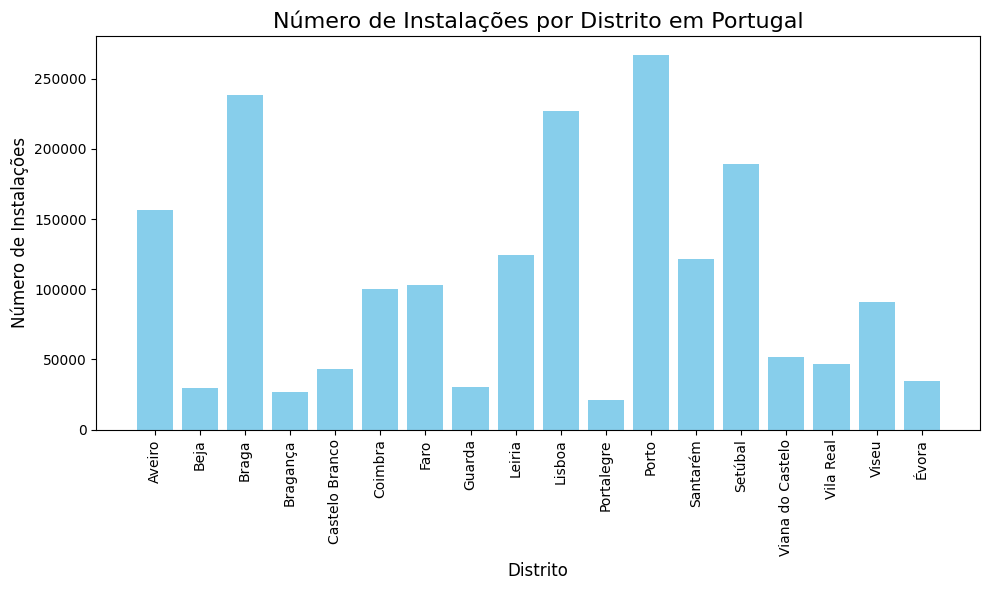

In [12]:
# Criar o gráfico de barras
plt.figure(figsize=(10,6))
plt.bar(tabela_instalacoes['Distrito'], tabela_instalacoes['Número de instalacões'], color='skyblue')

# Adicionar título e rótulos aos eixos
plt.title('Número de Instalações por Distrito em Portugal', fontsize=16)
plt.xlabel('Distrito', fontsize=12)
plt.ylabel('Número de Instalações', fontsize=12)

# Girar os rótulos dos distritos para evitar sobreposição
plt.xticks(rotation=90)

# Exibir o gráfico
plt.tight_layout()  # Ajustar o layout para evitar corte de texto
plt.show()

In [ ]:
mapa_pt = gpd.read_file('./pt.json')

# Verifique a coluna 'Distrito' no shapefile (verifique como a coluna de distrito está nomeada no shapefile)
# Exemplo: Se o nome da coluna for diferente de 'Distrito', você precisa ajustá-la
print(mapa_pt.columns)

# Unir o DataFrame com o shapefile usando a coluna 'Distrito'
mapa_pt = mapa_pt.merge(tabela_instalacoes, left_on='Distrito', right_on='Distrito', how='left')

# Verifique se a fusão foi feita corretamente
print(mapa_pt.head())

# Exibir as colunas do GeoDataFrame para ver se a coluna de número de instalações foi integrada

Index(['id', 'ISO', 'NAME_0', 'ID_1', 'NAME_1', 'VARNAME_1', 'HASC_1',
       'TYPE_1', 'ENGTYPE_1', 'geometry'],
      dtype='object')
     id  ISO    NAME_0  ID_1             NAME_1 VARNAME_1 HASC_1    TYPE_1  \
0  None  PRT  Portugal  2417      Ilha do Faial            PT.AV  Distrito   
1  None  PRT  Portugal  2417  Ilha de São Jorge            PT.AV  Distrito   
2  None  PRT  Portugal  2417   Ilha da Graciosa            PT.AV  Distrito   
3  None  PRT  Portugal  2417      Ilha Terceira            PT.AV  Distrito   
4  None  PRT  Portugal  2417    Ilha das Flores            PT.AV  Distrito   

  ENGTYPE_1                                           geometry Distrito  \
0  District  MULTIPOLYGON (((-12.0354 40.43343, -12.05374 4...      NaN   
1  District  MULTIPOLYGON (((-11.356 40.64004, -11.05809 40...      NaN   
2  District  MULTIPOLYGON (((-11.28671 40.86463, -11.30802 ...      NaN   
3  District  MULTIPOLYGON (((-10.81223 40.64686, -10.82427 ...      NaN   
4  District  MULTIPO

<Figure size 1200x800 with 0 Axes>

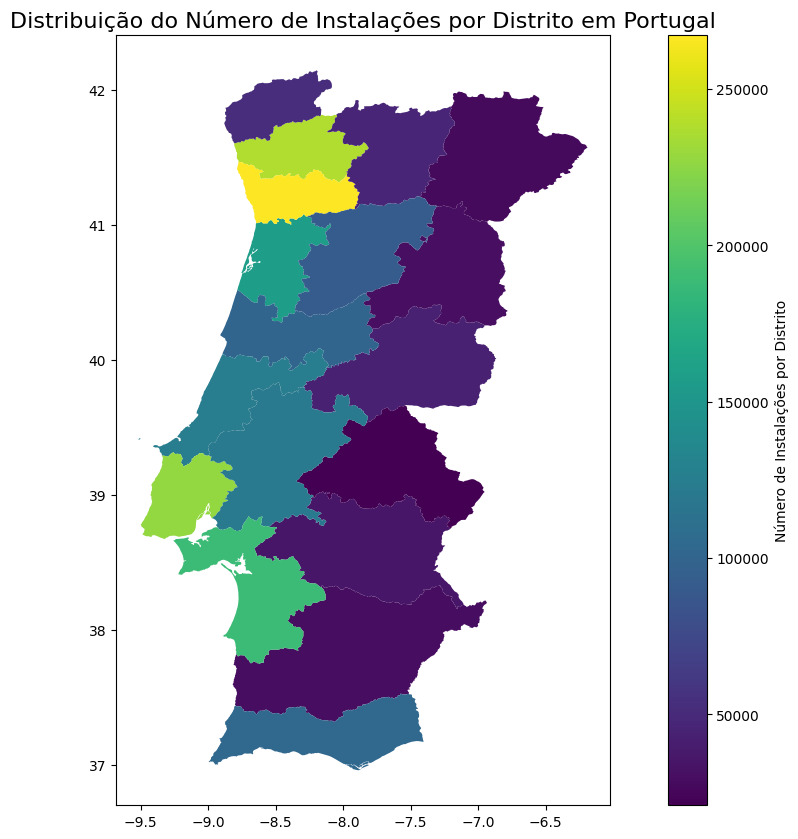

In [18]:
# Plotar o mapa com um gradiente para o número de instalações
plt.figure(figsize=(12, 8))

# Plotando o mapa e colorindo pelos números de instalações
# 'Número de instalacões' deve ser a coluna que contém os valores
# Use 'viridis' para um gradiente de cores ou qualquer outro que preferir
mapa_pt.plot(column='Número de instalacões', 
             cmap='viridis', 
             legend=True, 
             figsize=(15, 10), 
             legend_kwds={'label': "Número de Instalações por Distrito", 'orientation': "vertical"})

# Adicionar título
plt.title("Distribuição do Número de Instalações por Distrito em Portugal", fontsize=16)

# Exibir o mapa
plt.show()
